# Vibrational Density of States (VDOS) Tutorial

The vibrational density of states can be obtained from the Fourier transform of the velocity autocorrelation
function (VACF). The velocities must be the true time derivatives of the positions, so the production run
has to be **microcanonical (NVE)**: a thermostat (Nose-Hoover or Langevin) rescales or perturbs the velocities and
distorts the spectrum.

This notebook covers:

1. Thermalising a glass at 300 K in NVT
2. An NVE production run with `md_simulation(..., ensemble="nve")`, dumping velocities every 5 fs
3. Checking energy conservation
4. Computing the mass-weighted VACF and the total and partial (Si, O) VDOS with plain numpy

Units: positions in Å, time in fs (frequencies in THz), energies in eV. Velocities returned by `md_simulation`
are in Å/fs.

The VACF/VDOS code below is a minimal, self-contained illustration with a single trajectory block. Dedicated
library functions (block averaging, windows, partials by oxygen class and Qn) will be added to amorphouspy later.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read

import amorphouspy as am

## Setup

A 300-atom SiO$_2$ glass and the PMMCS potential. The run lengths are kept short so the notebook runs in a few
minutes; production VDOS calculations should use longer NVE runs and average over several blocks.

In [2]:
glass = read("data/SiO2_glass_300_atoms.xyz")
potential = am.generate_potential(am.get_structure_dict({"SiO2": 100}, target_atoms=9), potential_type="pmmcs")
print(glass)

Atoms(symbols='O200Si100', pbc=True, cell=[[16.48757572410817, 3.0287185254343006e-15, 3.028718525434301e-15], [-2.019145683487156e-15, 16.487575723, 3.0287185252307334e-15], [-2.0191456834871554e-15, -2.019145683487156e-15, 16.487575723]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)


## Step 1 — Thermalise at 300 K (NVT)

The NVE run starts from the velocities carried by the structure, so the glass is first equilibrated with a
thermostat. The returned structure carries the final velocities.

In [3]:
result_nvt = am.md_simulation(
    structure=glass,
    potential=potential,
    ensemble="nvt",
    temperature_sim=300.0,
    production_steps=10_000,  # 10 ps
    n_dump=None,
    n_print_thermo=100,
    seed=42,
)
glass_300K = result_nvt["structure"]
print(f"Final NVT temperature: {result_nvt['result']['temperature'][-1]:.1f} K")

Final NVT temperature: 321.4 K


## Step 2 — NVE production

`ensemble="nve"` writes `fix ensemble all nve` (no thermostat, no barostat) and keeps the velocities of the input
structure (no `velocity create`). `temperature_sim`, `temperature_end`, `npt_pressure` and `npt_pressure_end` are
not allowed with this ensemble and raise a `ValueError`.

Velocities are dumped every 5 fs, which resolves frequencies up to the Nyquist limit of 100 THz (the highest
Si–O stretching modes lie near 35 THz).

In [4]:
dump_every = 5  # MD steps
timestep_fs = 1.0

result_nve = am.md_simulation(
    structure=glass_300K,
    potential=potential,
    ensemble="nve",
    timestep=timestep_fs,
    production_steps=10_000,  # 10 ps
    n_dump=dump_every,
    n_print_thermo=dump_every,
)
nve = result_nve["result"]
print(f"Mean NVE temperature: {np.mean(nve['temperature']):.1f} K")

Mean NVE temperature: 309.2 K


## Step 3 — Energy conservation

In NVE the total energy must be conserved. The drift per atom per picosecond is a quick check of the timestep
and the potential cutoffs.

Total-energy drift: 0.0013 meV/atom/ps, fluctuation (std): 0.0077 meV/atom


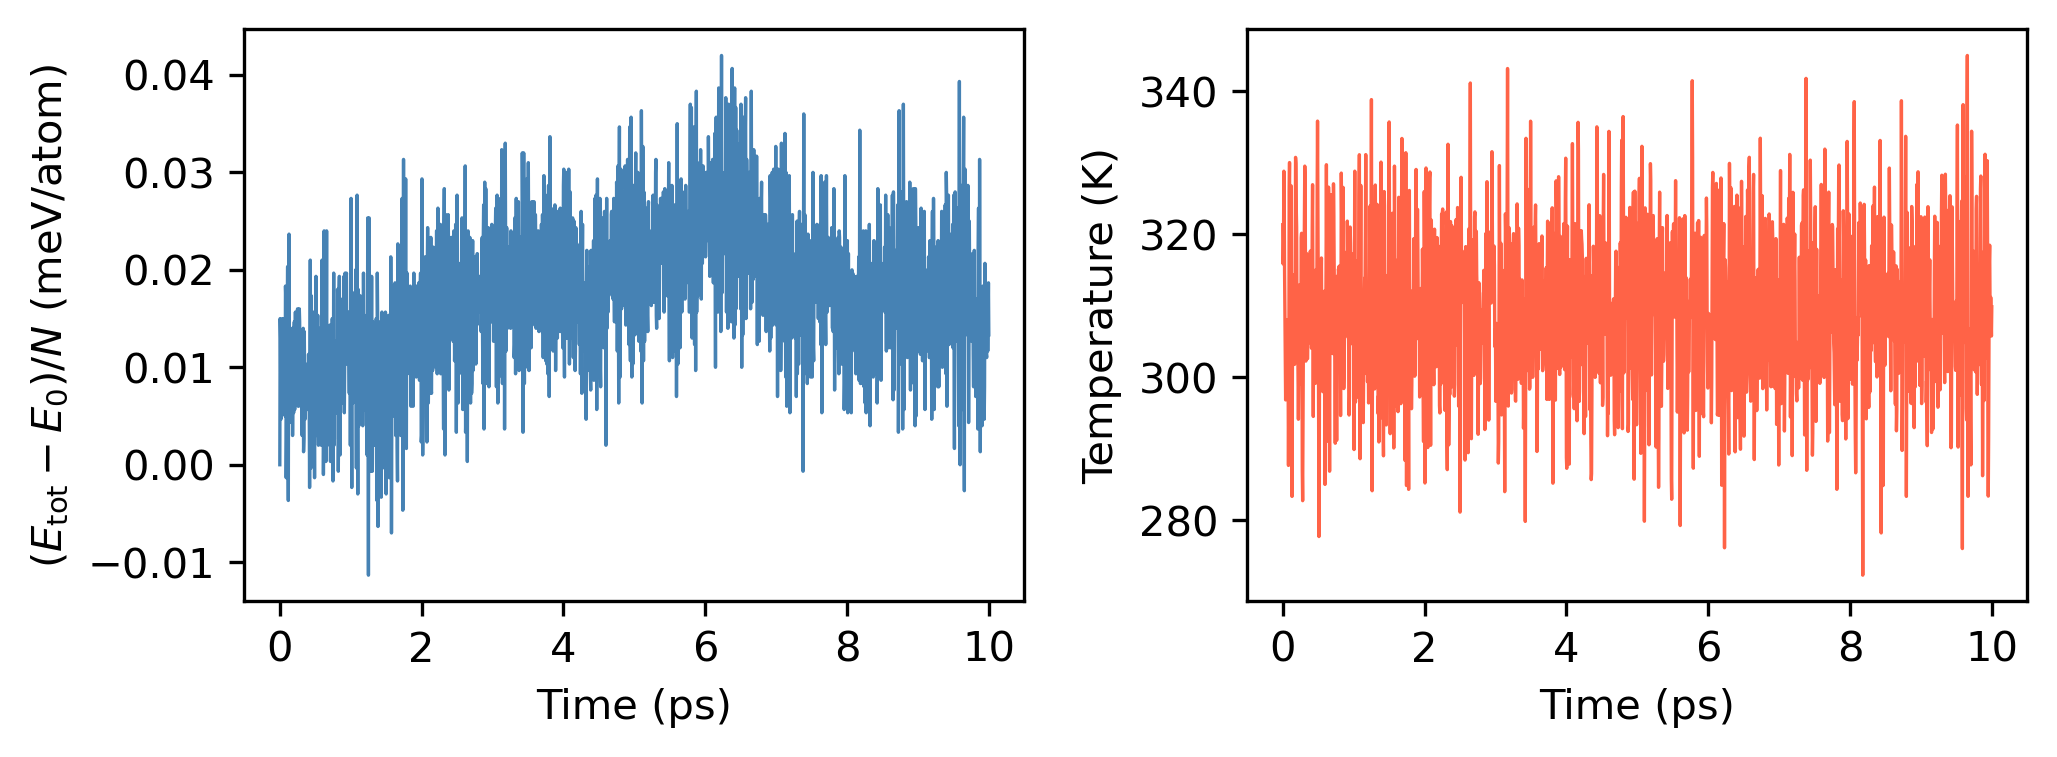

In [5]:
time_ps = np.asarray(nve["steps"]) * timestep_fs * 1e-3
e_tot = np.asarray(nve["energy_tot"])
n_atoms = len(glass)

drift = (e_tot[-1] - e_tot[0]) / n_atoms / (time_ps[-1] - time_ps[0]) * 1e3
fluct = np.std(e_tot) / n_atoms * 1e3
print(f"Total-energy drift: {drift:.4f} meV/atom/ps, fluctuation (std): {fluct:.4f} meV/atom")

_fig, axes = plt.subplots(1, 2, figsize=(3.5 * 2, 3.5 / 1.3333), dpi=300)
axes[0].plot(time_ps, (e_tot - e_tot[0]) / n_atoms * 1e3, lw=0.8, color="steelblue")
axes[0].set_xlabel("Time (ps)")
axes[0].set_ylabel(r"$(E_\mathrm{tot} - E_0)/N$ (meV/atom)")
axes[1].plot(time_ps, nve["temperature"], lw=0.8, color="tomato")
axes[1].set_xlabel("Time (ps)")
axes[1].set_ylabel("Temperature (K)")
plt.tight_layout()
plt.show()

A structure without velocities is rejected, so a forgotten equilibration cannot pass silently:

In [6]:
cold = glass.copy()
cold.set_velocities(np.zeros((len(cold), 3)))
try:
    am.md_simulation(structure=cold, potential=potential, ensemble="nve", production_steps=10)
except ValueError as exc:
    print(f"ValueError: {exc}")

ValueError: ensemble 'nve' with initial_temperature 0 needs a structure that carries non-zero velocities.


## Step 4 — Velocity autocorrelation function

The mass-weighted, normalised VACF is

$$C(t) = \frac{\sum_i m_i \langle \mathbf{v}_i(0)\cdot\mathbf{v}_i(t)\rangle}{\sum_i m_i \langle \mathbf{v}_i^2\rangle},$$

averaged over all time origins. It is computed with FFTs (Wiener–Khinchin theorem); zero padding to twice the
trajectory length avoids circular wrap-around. Per-element contributions use the same normalisation, so the
partial VACFs (and VDOS) sum exactly to the total.

velocities shape: (2001, 300, 3)
Mean kinetic temperature from dumped velocities: 309.2 K
C(0) = 1.000000


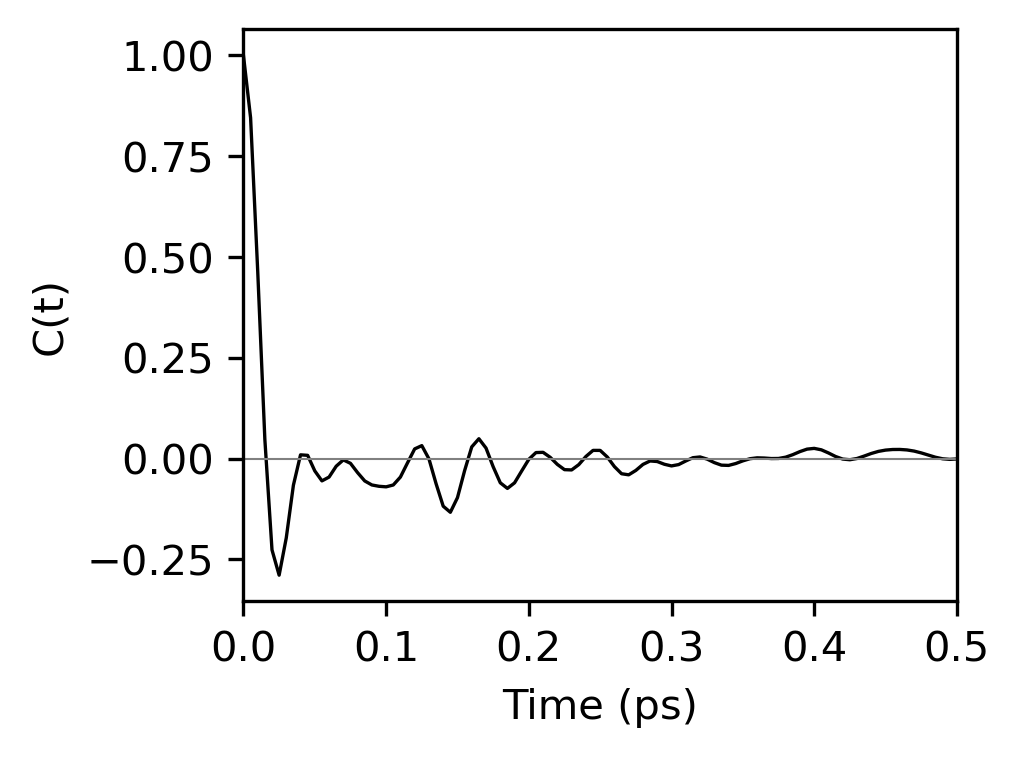

In [7]:
velocities = np.asarray(nve["velocities"])  # (n_frames, n_atoms, 3), Å/fs
masses = glass.get_masses()  # amu
symbols = np.array(glass.get_chemical_symbols())
n_frames = velocities.shape[0]
dt_ps = dump_every * timestep_fs * 1e-3
print("velocities shape:", velocities.shape)

# Consistency check: kinetic temperature from the dumped velocities (LAMMPS uses 3N - 3 degrees of freedom).
amu_A2_fs2_to_eV = 103.6427
k_B = 8.617333e-5  # eV/K
kinetic = 0.5 * np.einsum("i,fij->f", masses, velocities**2) * amu_A2_fs2_to_eV
t_kin = 2 * kinetic / ((3 * n_atoms - 3) * k_B)
print(f"Mean kinetic temperature from dumped velocities: {t_kin.mean():.1f} K")


def autocorrelation(signal: np.ndarray) -> np.ndarray:
    """Time-origin-averaged autocorrelation along axis 0 for every column, via zero-padded FFT."""
    n = signal.shape[0]
    spectrum = np.fft.rfft(signal, n=2 * n, axis=0)
    acf = np.fft.irfft(spectrum * spectrum.conj(), axis=0)[:n]
    return acf / (n - np.arange(n))[:, None]


# Per-atom autocorrelation summed over x, y, z: shape (n_frames, n_atoms)
acf_atoms = autocorrelation(velocities.reshape(n_frames, -1)).reshape(n_frames, n_atoms, 3).sum(axis=2)
n_lags = n_frames // 2  # only use lags with at least n/2 time origins
weighted = acf_atoms[:n_lags] * masses
norm = weighted[0].sum()
vacf = {"total": weighted.sum(axis=1) / norm}
for element in ("Si", "O"):
    vacf[element] = weighted[:, symbols == element].sum(axis=1) / norm
lag_ps = np.arange(n_lags) * dt_ps
print(f"C(0) = {vacf['total'][0]:.6f}")

_fig, ax = plt.subplots(figsize=(3.5, 3.5 / 1.3333), dpi=300)
ax.plot(lag_ps, vacf["total"], lw=0.8, color="black")
ax.axhline(0.0, color="gray", lw=0.5)
ax.set_xlim(0, 0.5)
ax.set_xlabel("Time (ps)")
ax.set_ylabel("C(t)")
plt.tight_layout()
plt.show()

## Step 5 — VDOS

The VDOS is the cosine transform of the VACF,

$$g(\nu) \propto \int_0^{t_\mathrm{max}} C(t)\, w(t) \cos(2\pi\nu t)\, dt,$$

where $w(t)$ is the decaying half of a Hann window, which suppresses truncation ripples at the cost of some
broadening. It is evaluated with an FFT of the even extension of $C(t)\,w(t)$ and normalised to
$\int g(\nu)\, d\nu = 1$. With a 5 ps maximum lag the frequency resolution is about 0.2 THz.

Integral of total VDOS: 1.0000
max |g_Si + g_O - g_total|: 2.78e-17


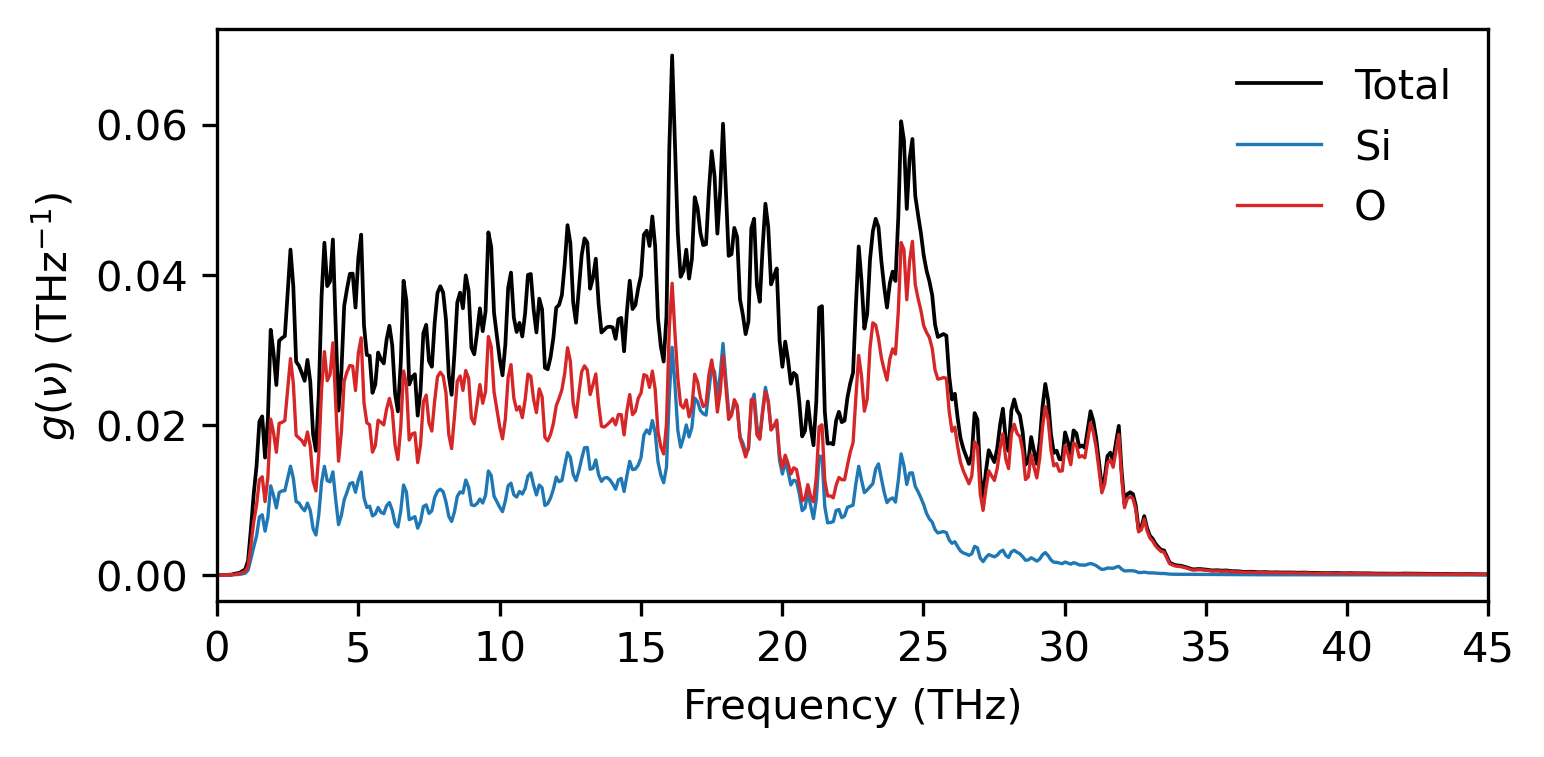

In [8]:
window = np.hanning(2 * n_lags)[n_lags:]


def cosine_transform(curve: np.ndarray) -> np.ndarray:
    """Real FFT of the even extension of the windowed curve."""
    tapered = curve * window
    even = np.concatenate([tapered, tapered[-1:0:-1]])
    return np.fft.rfft(even).real * dt_ps


freq_thz = np.fft.rfftfreq(2 * n_lags - 1, d=dt_ps)
vdos = {key: cosine_transform(curve) for key, curve in vacf.items()}
area = np.trapezoid(vdos["total"], freq_thz)
vdos = {key: values / area for key, values in vdos.items()}

print(f"Integral of total VDOS: {np.trapezoid(vdos['total'], freq_thz):.4f}")
print(f"max |g_Si + g_O - g_total|: {np.abs(vdos['Si'] + vdos['O'] - vdos['total']).max():.2e}")

_fig, ax = plt.subplots(figsize=(3.5 * 1.5, 3.5 / 1.3333), dpi=300)
ax.plot(freq_thz, vdos["total"], lw=0.9, color="black", label="Total")
ax.plot(freq_thz, vdos["Si"], lw=0.8, color="tab:blue", label="Si")
ax.plot(freq_thz, vdos["O"], lw=0.8, color="tab:red", label="O")
ax.set_xlim(0, 45)
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel(r"$g(\nu)$ (THz$^{-1}$)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

For SiO$_2$ glass the experimental and ab initio spectra show a low-frequency band below ~5 THz, a broad band
around 12–15 THz (Si–O–Si bending), and Si–O stretching bands near 24 THz and 32–36 THz. Band positions and
intensities obtained with a classical potential such as PMMCS can be shifted with respect to these values; the
single 10 ps block used here is also noisy. Longer NVE runs averaged over several blocks are needed for
quantitative work.

## Quick Reference

| Step | Call | Ensemble |
|------|------|----------|
| Thermalise | `am.md_simulation(structure, potential, ensemble="nvt", temperature_sim=T)` | NVT |
| Production | `am.md_simulation(result["structure"], potential, ensemble="nve", n_dump=5)` | NVE |
| Velocities | `result["result"]["velocities"]`, shape `(n_frames, n_atoms, 3)`, Å/fs | — |